In [3]:
import pandas as pd 
import numpy as np 

In [4]:
df = pd.read_csv("/Users/ankushchoudhari76/Downloads/ambient_temperature_system_failure.csv")

In [5]:
df.shape

(7267, 2)

In [6]:
df.head(10)

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551
5,2013-07-04 05:00:00,70.060966
6,2013-07-04 06:00:00,69.279765
7,2013-07-04 07:00:00,69.369608
8,2013-07-04 08:00:00,69.166714
9,2013-07-04 09:00:00,68.986083


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB


In [8]:
df['value'].mean()

np.float64(71.24243270828815)

<Axes: xlabel='timestamp'>

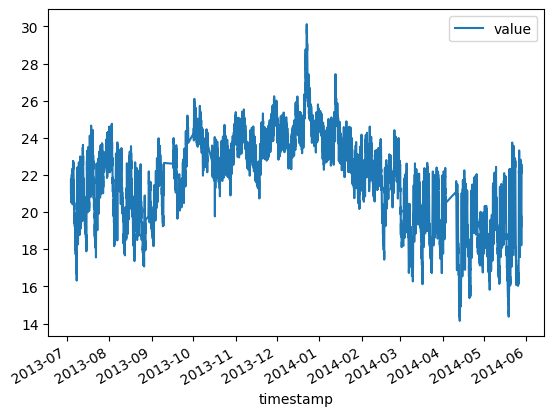

In [9]:
df['timestamp']=pd.to_datetime(df['timestamp'])
# change fahrenheit to °C (temperature mean= 71 -> fahrenheit)
df['value'] =(df['value']-32)*5/9

df.plot(x='timestamp' ,y='value')

In [10]:
# the hours and if it's night or day (7:00-22:00)
df['hours'] = df['timestamp'].dt.hour
df['daylight'] = ((df['hours'] >= 7) & (df['hours'] <= 22)).astype(int)

In [11]:
df.head(10)

,timestamp,value,hours,daylight
0,2013-07-04 00:00:00,21.044908,0,0
1,2013-07-04 01:00:00,21.789015,1,0
2,2013-07-04 02:00:00,21.598781,2,0
3,2013-07-04 03:00:00,20.533000,3,0
4,2013-07-04 04:00:00,20.713084,4,0
5,2013-07-04 05:00:00,21.144981,5,0
6,2013-07-04 06:00:00,20.710980,6,0
7,2013-07-04 07:00:00,20.760894,7,1
8,2013-07-04 08:00:00,20.648174,8,1
9,2013-07-04 09:00:00,20.547824,9,1


In [12]:
# the day of the week (Monday=0, Sunday=6) and if it's a week end day or week day.
df['DayOfTheWeek'] = df['timestamp'].dt.dayofweek
df['WeekDay'] = (df['DayOfTheWeek'] < 5).astype(int)
# An estimation of anomly population of the dataset (necessary for several algorithm)
outliers_fraction = 0.01

In [13]:
df.head(5)

,timestamp,value,hours,daylight,DayOfTheWeek,WeekDay
0,2013-07-04 00:00:00,21.044908,0,0,3,1
1,2013-07-04 01:00:00,21.789015,1,0,3,1
2,2013-07-04 02:00:00,21.598781,2,0,3,1
3,2013-07-04 03:00:00,20.533000,3,0,3,1
4,2013-07-04 04:00:00,20.713084,4,0,3,1


In [14]:
# time with int to plot easily
df['time_epoch'] = (df['timestamp'].astype(np.int64)/100000000000).astype(np.int64)

In [15]:
df.head(5)

,timestamp,value,hours,daylight,DayOfTheWeek,WeekDay,time_epoch
0,2013-07-04 00:00:00,21.044908,0,0,3,1,13728960
1,2013-07-04 01:00:00,21.789015,1,0,3,1,13728996
2,2013-07-04 02:00:00,21.598781,2,0,3,1,13729032
3,2013-07-04 03:00:00,20.533000,3,0,3,1,13729068
4,2013-07-04 04:00:00,20.713084,4,0,3,1,13729104


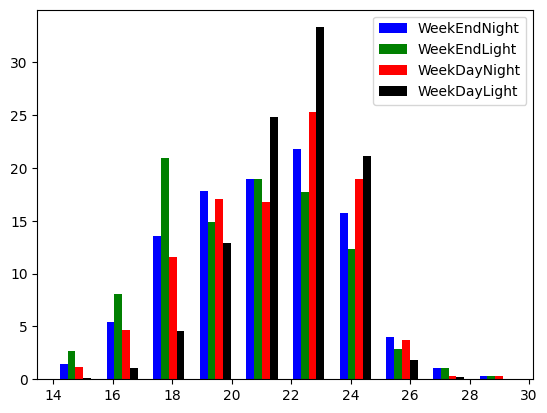

In [16]:
# creation of 4 distinct categories that seem useful (week end/day week & night/day)
import matplotlib.pyplot as plt 
df['categories'] = df['WeekDay']*2 + df['daylight']
a = df.loc[df['categories'] == 0, 'value']
b = df.loc[df['categories'] == 1, 'value']
c = df.loc[df['categories'] == 2, 'value']
d = df.loc[df['categories'] == 3, 'value']

fig, ax = plt.subplots()
a_heights, a_bins = np.histogram(a)
b_heights, b_bins = np.histogram(b, bins=a_bins)
c_heights, c_bins = np.histogram(c, bins=a_bins)
d_heights, d_bins = np.histogram(d, bins=a_bins)

width = (a_bins[1] - a_bins[0])/6

ax.bar(a_bins[:-1], a_heights*100/a.count(), width=width, facecolor='blue', label='WeekEndNight')
ax.bar(b_bins[:-1]+width, (b_heights*100/b.count()), width=width, facecolor='green', label ='WeekEndLight')
ax.bar(c_bins[:-1]+width*2, (c_heights*100/c.count()), width=width, facecolor='red', label ='WeekDayNight')
ax.bar(d_bins[:-1]+width*3, (d_heights*100/d.count()), width=width, facecolor='black', label ='WeekDayLight')

plt.legend()
plt.show()

## Modal 


In [17]:
from sklearn import preprocessing

data = df[['value', 'hours', 'daylight', 'DayOfTheWeek', 'WeekDay']]
min_max_scaler = preprocessing.StandardScaler()
np_scaled = min_max_scaler.fit_transform(data)
data = pd.DataFrame(np_scaled)
# reduce to 2 importants features

In [18]:
data.head(10)

,0,1,2,3,4
0,-0.320586,-1.661537,-1.414798,0.005769,0.62132
1,-0.005228,-1.517172,-1.414798,0.005769,0.62132
2,-0.085851,-1.372807,-1.414798,0.005769,0.62132
3,-0.537536,-1.228442,-1.414798,0.005769,0.62132
4,-0.461215,-1.084077,-1.414798,0.005769,0.62132
5,-0.278174,-0.939713,-1.414798,0.005769,0.62132
6,-0.462107,-0.795348,-1.414798,0.005769,0.62132
7,-0.440953,-0.650983,0.706815,0.005769,0.62132
8,-0.488724,-0.506618,0.706815,0.005769,0.62132
9,-0.531254,-0.362253,0.706815,0.005769,0.62132


In [19]:
from sklearn.decomposition import PCA
# reduce to 2 importants features
pca = PCA(n_components=2)
data = pca.fit_transform(data)
# standardize these 2 new features
min_max_scaler = preprocessing.StandardScaler()
np_scaled = min_max_scaler.fit_transform(data)
data = pd.DataFrame(np_scaled)
data

,0,1
0,-0.066191,-1.755363
1,0.009413,-1.647609
2,0.009359,-1.577677
3,-0.061592,-1.543184
4,-0.031660,-1.458262
...,...,...
7262,0.663130,0.218870
7263,0.669607,0.292067
7264,0.679271,0.366858
7265,0.684664,0.439514


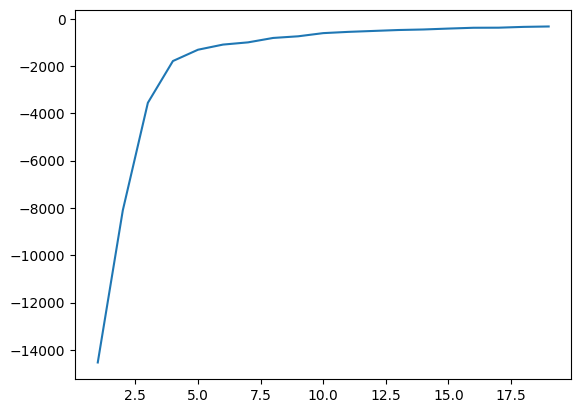

In [20]:
from sklearn.cluster import KMeans
n_cluster = range(1, 20)
kmeans = [KMeans(n_clusters=i).fit(data) for i in n_cluster]
scores = [kmeans[i].score(data) for i in range(len(kmeans))]
fig, ax = plt.subplots()
ax.plot(n_cluster, scores)
plt.show()

In [21]:
# Not clear for me, I choose 15 centroids arbitrarily and add these data to the central dataframe
df['cluster'] = kmeans[14].predict(data)
df['principal_feature1'] = data[0]
df['principal_feature2'] = data[1]
df['cluster'].value_counts()

cluster
5     661
4     596
11    591
2     581
10    567
9     566
14    541
8     476
3     456
1     454
7     400
0     357
13    350
12    339
6     332
Name: count, dtype: int64

In [22]:
df.head(10)

,timestamp,value,hours,daylight,DayOfTheWeek,WeekDay,time_epoch,categories,cluster,principal_feature1,principal_feature2
0,2013-07-04 00:00:00,21.044908,0,0,3,1,13728960,2,11,-0.066191,-1.755363
1,2013-07-04 01:00:00,21.789015,1,0,3,1,13728996,2,11,0.009413,-1.647609
2,2013-07-04 02:00:00,21.598781,2,0,3,1,13729032,2,11,0.009359,-1.577677
3,2013-07-04 03:00:00,20.533000,3,0,3,1,13729068,2,11,-0.061592,-1.543184
4,2013-07-04 04:00:00,20.713084,4,0,3,1,13729104,2,11,-0.031660,-1.458262
5,2013-07-04 05:00:00,21.144981,5,0,3,1,13729140,2,11,0.018663,-1.363146
6,2013-07-04 06:00:00,20.710980,6,0,3,1,13729176,2,11,-0.001131,-1.303081
7,2013-07-04 07:00:00,20.760894,7,1,3,1,13729212,3,14,0.220631,-0.093570
8,2013-07-04 08:00:00,20.648174,8,1,3,1,13729248,3,14,0.226853,-0.020499
9,2013-07-04 09:00:00,20.547824,9,1,3,1,13729284,3,14,0.234077,0.053072


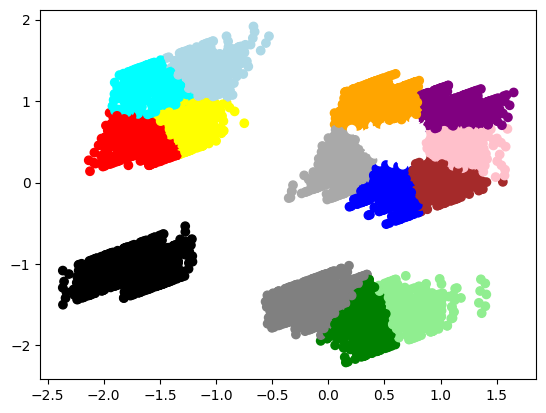

In [ ]:
#plot the different clusters with the 2 main features
fig, ax = plt.subplots()
colors = {0:'red', 1:'blue', 2:'green', 3:'pink', 4:'black', 5:'orange', 6:'cyan', 7:'yellow', 8:'brown', 9:'purple', 10:'white', 11: 'grey', 12:'lightblue', 13:'lightgreen', 14: 'darkgrey'}
ax.scatter(df['principal_feature1'], df['principal_feature2'], c=df["cluster"].apply(lambda x: colors[x]))
plt.show()